## Задание

### Часть 1 (5 балла)
1. Выберите одну любую из задач, рассмотренных на [лекции](https://colab.research.google.com/drive/1B7Np_7y002NLiuNkriq6a6MchQL4Fw7p?usp=sharing) (локализация, сегментация, перенос стиля, генерация).

2. Подберите на kaggle датасет, подходящий для решения этой задачи.
  - Вариант 1: если данные обладают необходимой разметкой, то повторите пайплайн из блокнота с примером на своих данных.
  - Вариант 2: если данные не обладают необходимой разметкой, то используйте модель, которую дообучали в примере, но без дообучения.
3. Оцените и прокомментируйте результат.

### Часть 2 (8 баллов)
1. Выберите еще одну из рассмотренных в лекции задач (не совпадающую с первой).
2. Если ваши данные обладают разметкой, необходимой для новой задачи, продолжите работу с ними. Если нет, найдите другой датасет, в котором она будет. Можно взять какой-нибудь стандартный в PyTorch, но такой, который не встречался ни в одном из примеров с лекции. В этом задании обязательно нужно найти датасет с разметкой.
3. Повторите пайплайн из примера.
4. Постарайтесь улучшить качество результата (если классификация - точность выше 90%, во всех остальных - максимально понизить лосс). Это можно сделать за счет настройки гиперпараметров. Можно (опционально и в зависимости от задачи) также поменять гиперпараметры в слоях нейронных сетей и/или порядок слоев и/или их количество.

В заданиях, где перечислены два варианта выполнения, нужно выбрать только один. Выполнение обоих дополнительных баллов не дает.



## Выполнение задания

### Часть 1. Перенос стиля

#### Выбор датасета

Для задачи переноса стиля нам не нужен размеченный датасет -- возьмем  две картинки из датасета [WikiArt Art Movements/Styles](https://www.kaggle.com/datasets/sivarazadi/wikiart-art-movementsstyles). Этот датасет представляет из себя коллекцию изображений произведений искусства, собранных с ресурса WikiArt, с разделением по художественным стилям.

Попробуем налажить один стиль на другой -- неоклассицизм на классическую академическую работу.



#### Загрузка предобученной модели

Загружаем предобученную модель VGG19 -- это сверточная нейросеть, обученная на огромном наборе данных ImageNet.

В задачах переноса стиля нас интересуют внутренние признаки изображения, извлекаемые сверточными слоями VGG известна тем, что её сверточные слои хорошо "видят" текстуры, контуры и стиль изображения.

In [ ]:
import torch
from torchvision import models

vgg = models.vgg19(pretrained=True)
print(vgg)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:10<00:00, 55.0MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
vgg = vgg.features
print(vgg)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [ ]:
for parameters in vgg.parameters():
  parameters.requires_grad_(False)

In [ ]:
vgg.to(device)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

#### Предобработка изображений

Предобработаем изображения, так как нейросеть VGG19 ожидает вход тензор с размерностью (batch, channels, height, width) и нормализованный по определённым средним и стандартным отклонениям.

In [ ]:
from PIL import Image
from torchvision import transforms as T

def preprocess(img_path, max_size=500):
  image = Image.open(img_path).convert("RGB")
  if max(image.size) > max_size:
    size = max_size
  else:
    size = max(image.size)

  img_transforms = T.Compose([
      T.Resize(size),
      T.ToTensor(),
      T.Normalize(mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225])
  ])
  image = img_transforms(image)
  image = image.unsqueeze(0) # (3, 224, 224) -> (1, 3, 224, 224)

  return image

Также загрузим котент (изображение, которое хотим стилизовать) и стиль (изображение, чей стиль хотим перенести).

In [ ]:
import kagglehub, os

path = kagglehub.dataset_download("sivarazadi/wikiart-art-movementsstyles")
content_path = os.path.join(path, "Academic_Art", "Academic_Art", "232331.jpg")
style_path = os.path.join(path, "Expressionism", "Expressionism", "185354.jpg")

Using Colab cache for faster access to the 'wikiart-art-movementsstyles' dataset.


In [ ]:
content_preprocess = preprocess(content_path)
style_preprocess = preprocess(style_path)

content_preprocess = content_preprocess.to(device)
style_preprocess = style_preprocess.to(device)

print(f"Content shape {content_preprocess.shape}")
print(f"Style shape {style_preprocess.shape}")

Content shape torch.Size([1, 3, 500, 636])
Style shape torch.Size([1, 3, 674, 500])


Реализуем преобразование, чтобы отобразить изображение после обработки нейросетью.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def deprocess(tensor):
  image = tensor.to("cpu").clone()
  image = image.numpy()
  image = image.squeeze(0) # (1, 3, 224, 224) -> (3, 224, 224)
  image = image.transpose(1, 2, 0) # (3, 224, 224) -> (224, 224, 3)
  image = image * np.array([0.485, 0.456, 0.406]) + np.array([0.229, 0.224, 0.225])
  image = image.clip(0,1)

  return image

In [ ]:
content_deproc = deprocess(content_preprocess)
style_deproc = deprocess(style_preprocess)

print(f"Deprocess content: {content_deproc.shape}")
print(f"Deprocess style: {style_deproc.shape}")

Deprocess content: (500, 636, 3)
Deprocess style: (674, 500, 3)


Посмотрим на изображения, чтобы убедиться, что всё загрузилось корректно.

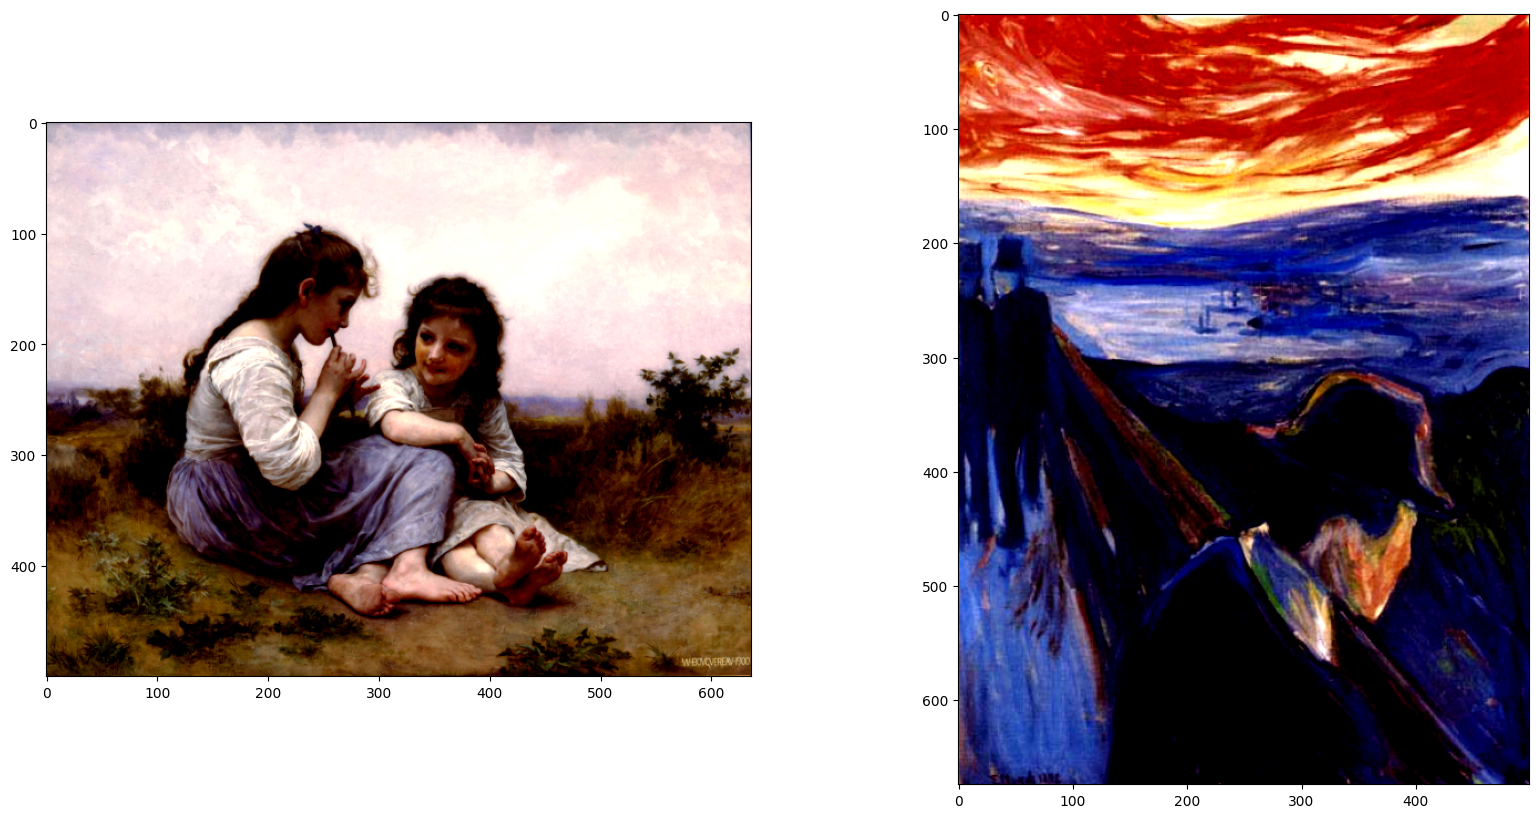

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(20,10))
ax1.imshow(content_deproc)
ax2.imshow(style_deproc);

#### Извлечение признаков из картинки и стиля, построение матрицы Грама

Пропускаем изображение через VGG19 и сохраняем признаки (feature maps) определённых слоёв. Признаки контента нужны, чтобы новая картинка сохраняла форму исходного изображения. Признаки стиля нужны, чтобы перенести узоры и текстуры.

In [ ]:
def get_features(image, model):
  layers = {
      "0": "conv1_1",  # see representaion.png
      "5": "conv2_1",
      "10": "conv3_1",
      "19": "conv4_1",
      "21": "conv4_2", #content_feature
      "28": "conv5_1"
  }

  x = image
  Features = {}
  for name, layer in model._modules.items():
    x = layer(x)
    if name in layers:
      Features[layers[name]] = x

  return Features

In [ ]:
content_features = get_features(content_preprocess, vgg)
style_features = get_features(style_preprocess, vgg)

Матрица Грама показывает корреляцию между каналами признаков.

Для каждого слоя выбранной VGG19 мы строим матрицу Грама. Это «отпечаток стиля» исходного изображения.

Мы берём матрицу Грама изображения-контента и сравниваем с матрицей Грамма для стиля. Минимизируем разницу и target начинает иметь те же текстурные зависимости между каналами, что и стиль.

In [ ]:
def gram_matrix(tensor):
  b, c, h, w = tensor.size()
  tensor = tensor.view(c, h*w)
  gram = torch.mm(tensor, tensor.t())
  return gram

In [ ]:
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

#### Создание функций потерь для картинки и стиля

In [ ]:
def content_loss(target_conv4_2, content_conv4_2):
  loss = torch.mean((target_conv4_2-content_conv4_2)**2)
  return loss

In [ ]:
style_weights = {
    "conv1_1": 1.0,
    "conv2_1": 0.75,
    "conv3_1": 0.75,
    "conv4_1": 0.75,
    "conv5_1": 0.75
}

In [ ]:
def style_loss(style_weights, target_fs, style_grams):
  loss = 0
  for layer in style_weights:
    target_feature = target_fs[layer]
    target_gram = gram_matrix(target_feature)
    style_gram = style_grams[layer]
    b, c, h, w = target_feature.shape
    layer_loss = style_weights[layer]*torch.mean((target_gram-style_gram)**2)
    loss += layer_loss/(c*h*w)

  return loss

In [ ]:
target = content_preprocess.clone().requires_grad_(True).to(device)
target_f = get_features(target,vgg)
print(f"Content loss: {content_loss(target_f['conv4_2'], content_features['conv4_2'])}")
print(f"Style loss: {style_loss(style_weights, target_f,style_grams)}")

Content loss: 0.0
Style loss: 85.27055358886719


#### Обучение модели

In [ ]:
from torch import optim

optimizer = optim.Adam([target],lr=0.003)

alpha = 1.0
beta = 1e5
epochs = 4000
show_every = 500

In [ ]:
def total_loss(c_loss, s_loss, alpha, beta):
  loss = alpha*c_loss + beta*s_loss
  return loss

In [ ]:
results = []

for i in range(epochs):
  target_f = get_features(target,vgg)
  c_loss = content_loss(target_f["conv4_2"], content_features["conv4_2"])
  s_loss = style_loss(style_weights, target_f, style_grams)
  t_loss = total_loss(c_loss,s_loss, alpha, beta)

  optimizer.zero_grad()
  t_loss.backward()
  optimizer.step()

  if i % show_every == 0:
    print(f"Total loss at Epoch {i}: {t_loss}")
    results.append(deprocess(target.detach()))

Total loss at Epoch 0: 8527055.0
Total loss at Epoch 500: 475768.34375
Total loss at Epoch 1000: 232704.375
Total loss at Epoch 1500: 138693.109375
Total loss at Epoch 2000: 85936.6328125
Total loss at Epoch 2500: 56560.68359375
Total loss at Epoch 3000: 39738.65234375
Total loss at Epoch 3500: 29423.021484375


Видим, что изначально потери очень высокая (≈8.5 млн), что естественно: target ещё полностью равен контенту, стиль не перенесён.
Быстрое падение потерь в первые 500–1000 эпох говорит о том, что изображение начинает адаптироваться к стилю.
Дальнейшее падение становится менее резким постепенным -- модель приближается к локальному минимуму.

Посмотрим на картинки визуально

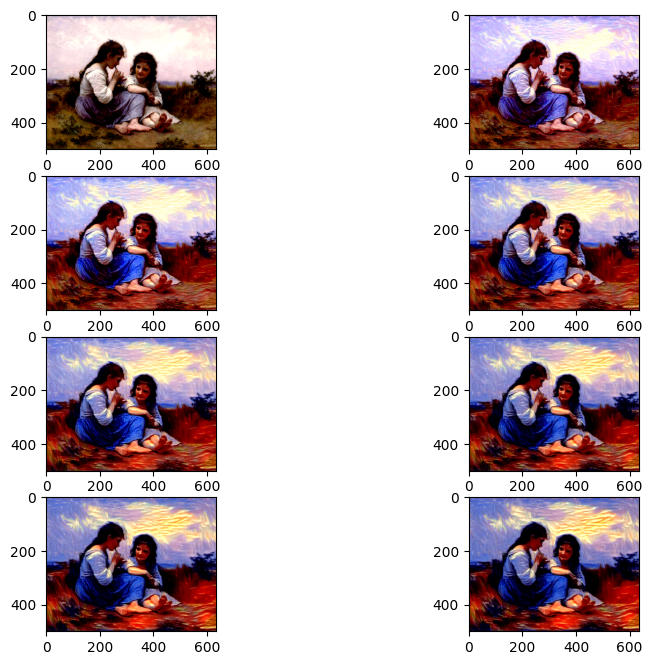

In [ ]:
plt.figure(figsize=(10,8))
for i,_ in enumerate(results):
  plt.subplot(4,2, i+1)
  plt.imshow(results[i])
plt.show()

Видно, что основные паттерны стиля перенесены. Визуально результат получился хорошим.

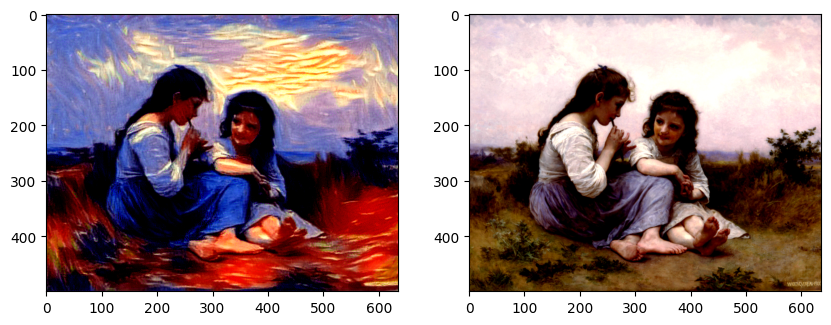

In [ ]:
target_copy = deprocess(target.detach())
content_copy = deprocess(content_preprocess)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.imshow(target_copy)
ax2.imshow(content_copy);

### Часть 2. Локализация (детектирование)

#### Выбор датасета

Для задачи детекции мы рассмотрим размеченный датасет [Face Mask Detection](https://www.kaggle.com/datasets/andrewmvd/face-mask-detection). Этот датасет предназначен для задач обнаружения лиц, на которых надеты маски, а также распознавания случаев, когда маска надета неверно (например, не закрывает нос).

Разметка датасета включает:

- Bounding boxes — координаты прямоугольников, ограничивающих каждое лицо на изображении.

- Классы (labels) для каждого объекта:

  - with_mask — лицо с правильно надетой маской,

  - without_mask — лицо без маски,

  - mask_weared_incorrect — маска надета неправильно (например, не закрыт нос).

Аннотации хранятся в формате .xml.

In [ ]:
import os, json
os.makedirs("/root/.kaggle", exist_ok=True)

from google.colab import files
files.upload()

!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d andrewmvd/face-mask-detection
!unzip -q face-mask-detection.zip -d face-mask-detection

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
 91% 361M/398M [00:00<00:00, 565MB/s]
100% 398M/398M [00:00<00:00, 523MB/s]


#### Предобработка данных

Переведем .xml аннотации в структурированную таблицу. аналогичную таблице ищ примера.

In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd

base_dir = "face-mask-detection"
img_dir = os.path.join(base_dir, "images")
ann_dir = os.path.join(base_dir, "annotations")

records = []

for fname in os.listdir(ann_dir):
    if not fname.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(ann_dir, fname))
    root = tree.getroot()

    filename = root.find("filename").text
    img_path = os.path.join("images", filename)

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    for obj in root.findall("object"):
        label = obj.find("name").text
        bndbox = obj.find("bndbox")

        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)

        records.append({
            "img_path": img_path,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "width": width,
            "height": height,
            "label": label
        })

df = pd.DataFrame(records)

In [ ]:
df.head()

,img_path,xmin,ymin,xmax,ymax,width,height,label
0,images/maksssksksss246.png,238,106,266,138,400,320,with_mask
1,images/maksssksksss246.png,192,130,212,150,400,320,with_mask
2,images/maksssksksss246.png,21,25,69,78,400,320,with_mask
3,images/maksssksksss246.png,336,151,344,160,400,320,with_mask
4,images/maksssksksss546.png,27,177,140,311,301,400,with_mask


In [ ]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
device = "cuda"

batch_size = 2
lr = 1e-4
epochs = 10
img_size = 140

model_name = "efficientnet_b0" #b3, b5, b7; resnet34, resnet50,

num_cor = 4

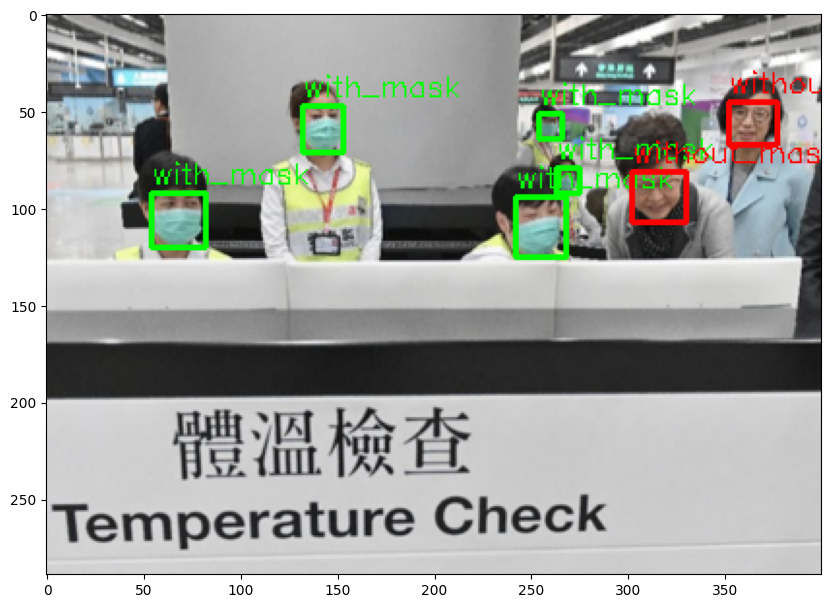

In [ ]:
img_name = df.iloc[20].img_path
img_path = os.path.join(base_dir, img_name)

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_copy = image.copy()

rows = df[df["img_path"] == img_name]

for _, row in rows.iterrows():
    pt1 = (row.xmin, row.ymin)
    pt2 = (row.xmax, row.ymax)
    label = row.label
    if row.label == "with_mask":
        color = (0,255,0)
    elif row.label == "without_mask":
        color = (255,0,0)
    else:  # mask_weared_incorrect
        color = (255,255,0)
    image_copy = cv2.rectangle(image_copy, pt1, pt2, color, 2)
    cv2.putText(image_copy, label, (row.xmin, row.ymin-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

plt.figure(figsize=(10,8))
plt.imshow(image_copy)

Нужно, чтобы модель обучалась на одних изображениях, а проверялась на других -- так мы избежим переобучения. Поэтому берём именно уникальные имена изображений, так как на одном изображении может быть более одной метки, и делим их на train (80%) и validation (20%).

In [ ]:
image_names = df["img_path"].unique()

train_img, val_img = train_test_split(image_names, test_size=0.2, random_state=42)
train_df = df[df["img_path"].isin(train_img)].reset_index(drop=True)
val_df = df[df["img_path"].isin(val_img)].reset_index(drop=True)

Для train применяем аугментации, для val только Resize без случайных трансформаций.

Аугментации увеличивают устойчивость модели к вариациям и помогают избежать переобучения.

#### Аугментация данных

In [ ]:
import albumentations as A

train_augs = A.Compose([
    A.Resize(img_size, img_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate()
],
bbox_params=A.BboxParams(
    format='pascal_voc',
    label_fields=['class_labels'],
    min_visibility=0.0
))

val_augs = A.Compose([
    A.Resize(img_size, img_size),
], bbox_params=A.BboxParams(
    format='pascal_voc',
    label_fields=['class_labels'],
    min_visibility=0.0
))

#### Класс для обработки датасета

Создаём кастомный Dataset, который умеет:
- Загружать изображение из img_dir.
- Находить все bounding boxes и метки для этого изображения в df.
- Применять аугментации вместе с корректировкой (обрезанием до границ изображения) боксов.
- Преобразовывать изображение в тензор (C,H,W) для PyTorch.
- Преобразовывать боксы в тензор FloatTensor размером (num_boxes, 4).

In [ ]:
import torch
import cv2
import os
import albumentations as A

class ObjectLocationDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, augmentations=None, img_size=140):
        self.df = df
        self.img_dir = img_dir
        self.augmentations = augmentations
        self.imgs = df["img_path"].unique()
        self.img_size = img_size

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        rows = self.df[self.df["img_path"] == img_name]

        bboxes = []
        labels = []
        for _, row in rows.iterrows():
            bboxes.append([row.xmin, row.ymin, row.xmax, row.ymax])
            labels.append(row.label)

        img_path = os.path.join(self.img_dir, os.path.basename(img_name))
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        valid_bboxes = []
        valid_labels = []
        h, w, _ = img.shape
        for i, b in enumerate(bboxes):
            x_min, y_min, x_max, y_max = b
            x_min = max(0, min(x_min, w-1))
            y_min = max(0, min(y_min, h-1))
            x_max = max(0, min(x_max, w-1))
            y_max = max(0, min(y_max, h-1))
            if x_max - x_min > 1 and y_max - y_min > 1:
                valid_bboxes.append([x_min, y_min, x_max, y_max])
                valid_labels.append(labels[i])

        bboxes = valid_bboxes
        labels = valid_labels

        # применяем аугментации
        if self.augmentations and len(bboxes) > 0:
            data = self.augmentations(image=img, bboxes=bboxes, class_labels=labels)
            img = data["image"]
            bboxes = data["bboxes"]
            labels = data["class_labels"]

            # обрезаем боксы после аугментаций на случай выхода за рамки
            h, w, _ = img.shape
            valid_bboxes = []
            valid_labels = []
            for i, b in enumerate(bboxes):
                x_min, y_min, x_max, y_max = b
                x_min = max(0, min(x_min, w-1))
                y_min = max(0, min(y_min, h-1))
                x_max = max(0, min(x_max, w-1))
                y_max = max(0, min(y_max, h-1))
                if x_max - x_min > 1 and y_max - y_min > 1:
                    valid_bboxes.append([x_min, y_min, x_max, y_max])
                    valid_labels.append(labels[i])
            bboxes = valid_bboxes
            labels = valid_labels

        img = torch.from_numpy(img).permute(2,0,1).float() / 255.0
        if len(bboxes) == 0:
            bboxes = torch.zeros((0,4), dtype=torch.float32)
        else:
            bboxes = torch.tensor(bboxes, dtype=torch.float32)

        return img, bboxes, labels


Создаём объекты trainset и valset, которые можно будет передавать в DataLoader для обучения модели.

In [ ]:
trainset = ObjectLocationDataset(
    df=train_df,
    img_dir=img_dir,
    augmentations=train_augs,
    img_size=img_size
)

valset = ObjectLocationDataset(
    df=val_df,
    img_dir=img_dir,
    augmentations=val_augs,
    img_size=img_size
)

In [ ]:
print(f"Total examples in the train set: {len(trainset)}")
print(f"Total examples in the validation set: {len(valset)}")

Total examples in the train set: 682
Total examples in the validation set: 171


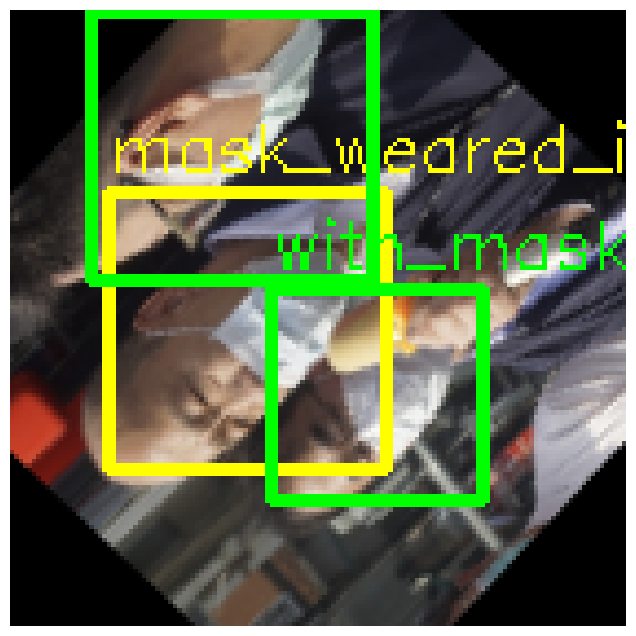

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

img, bboxes, labels = trainset[31]

img_np = img.permute(1, 2, 0).numpy()
img_np = (img_np * 255).astype(np.uint8)
bnd_img = img_np.copy()

if isinstance(labels, str):
    bboxes = [bboxes]
    labels = [labels]

for bbox, label in zip(bboxes, labels):
    xmin, ymin, xmax, ymax = map(int, bbox.tolist())
    pt1, pt2 = (xmin, ymin), (xmax, ymax)

    if label == "with_mask":
        color = (0,255,0)
    elif label == "without_mask":
        color = (255,0,0)
    else:
        color = (255,255,0)

    bnd_img = cv2.rectangle(bnd_img, pt1, pt2, color, 2)
    cv2.putText(bnd_img, label, (pt1[0], pt1[1]-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

plt.figure(figsize=(10,8))
plt.imshow(bnd_img)
plt.axis("off")
plt.show()


#### Разбиение датасета по батчам

In [ ]:
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
validloader = DataLoader(valset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [ ]:
print("Total no. batches in trainloader : {}".format(len(trainloader)))
print("Total no. batches in validloader : {}".format(len(validloader)))

Total no. batches in trainloader : 341
Total no. batches in validloader : 86


In [ ]:
for images, targets in trainloader:
    break

print("Batch size (images):", len(images))
print("Shape of one image tensor:", images[0].shape)

print("Number of bbox sets in batch:", len(targets))
print("Shape of first sample bboxes:", targets[0]["boxes"].shape)
print("Labels for first sample:", targets[0]["labels"])

Batch size (images): 2
Shape of one image tensor: torch.Size([3, 140, 140])
Number of bbox sets in batch: 2
Shape of first sample bboxes: torch.Size([2, 4])
Labels for first sample: tensor([1, 1])


#### Создание модели

Подход из предложенного примера в данной ситуации не подходит. Простая регрессия координат через MSELoss не учитывает, сколько объектов на изображении и где они расположены. Faster R-CNN решает это через RPN + ROI Pooling. Также в случае с примером нет классификации объектов вместе с координатами -- просто предсказываются координаты без учёта классов (with_mask, without_mask, mask_weared_incorrect).

Импортируем и создаём модель Faster R-CNN.

- Берём MobileNetV3 large как backbone (feature extractor).
- Настраиваем RPN (Region Proposal Network) с anchor’ами разных размеров и соотношений сторон.
- Настраиваем ROI Pooling, чтобы выровнять признаки для каждого предложения.

Создаём Faster R-CNN с 4 классами:
- 0 -- background
- 1 -- with_mask
- 2 -- without_mask
- 3 -- mask_weared_incorrect

In [ ]:
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torch.utils.data import DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [ ]:
class_to_idx = {
    "with_mask": 1,
    "without_mask": 2,
    "mask_weared_incorrect": 3
}

In [ ]:
def get_model(num_classes=4):
    backbone = torchvision.models.mobilenet_v3_large(weights="IMAGENET1K_V1").features
    backbone.out_channels = 960

    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )

    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'], output_size=7, sampling_ratio=2
    )

    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )
    return model

Faster R-CNN требует, чтобы батч был списком изображений и списком словарей targets. В ```collate_fn```:
- Объединяем данные разных изображений в батч.
- Преобразуем боксы и метки в тензоры.
- Обрабатываем случай, когда у изображения нет объектов.

In [ ]:
def collate_fn(batch):
    images, bboxes, labels = zip(*batch)
    targets = []
    for b, l in zip(bboxes, labels):
        if len(b) == 0:
            targets.append({
                "boxes": torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros((0,), dtype=torch.int64)
            })
        else:
            targets.append({
                "boxes": b.detach().clone() if isinstance(b, torch.Tensor) else torch.tensor(b, dtype=torch.float32),
                "labels": torch.tensor([class_to_idx[lab] for lab in l], dtype=torch.int64)
            })
    return list(images), targets

In [ ]:
model = get_model()
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

metric_map = MeanAveragePrecision()

#### Обучение модели

В процессе обучения будем смотреть на несколько стандартных для задачи детекции метрик

mAP (mean Average Precision):

- Измеряет среднюю точность детекции по всем классам и всем IoU (Intersection over Union) thresholds.

IoU (Intersection over Union): мера совпадения предсказанного бокса с истинным:
IoU = $\frac{Площадь \quad пересечения}{Площадь \quad объединения}$

mAP [0.5:0.95]:
- усреднённое значение Average Precision при разных порогах IoU от 0.5 до 0.95 с шагом 0.05.
- Более строгий показатель: показывает, насколько точно модель ставит боксы и распознаёт классы.

mAP 0.5:
- средняя точность при пороге IoU = 0.5.
- менее строгий критерий -- если IoU $\geq$ 0.5, предсказанный бокс считается правильным.

mAP 0.75:
- средняя точность при IoU = 0.75.
- более строгий критерий -- модель должна точнее выровнять предсказанный бокс с истинным.

mAR@100 (mean Average Recall):
- среднее значение Recall при ограничении до 100 предсказанных боксов на изображение.
- показывает способность модели не пропускать объекты, даже если точность бокса не идеальна.

In [ ]:
best_map = 0.0
for i in range(epochs):
    model.train()
    total_train_loss = 0.0
    for images, targets in tqdm(trainloader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_train_loss += losses.item()

    model.eval()
    metric_map.reset()
    with torch.no_grad():
        for images, targets in validloader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            preds = model(images)
            metric_map.update(preds, targets)

    metrics = metric_map.compute()
    val_map = metrics["map"].item()

    avg_train_loss = total_train_loss / len(trainloader)

    if val_map > best_map:
        torch.save(model.state_dict(), "best_model.pt")
        print("Weights Are Saved")
        best_map = val_map

    print(f"\nEpoch {i+1}:")
    print(f"  train loss: {avg_train_loss:.4f}")
    print(f"  mAP@[0.5:0.95]: {metrics['map']:.4f}")
    print(f"  mAP@0.5:       {metrics['map_50']:.4f}")
    print(f"  mAP@0.75:      {metrics['map_75']:.4f}")
    print(f"  mAR@100:       {metrics['mar_100']:.4f}")

  0%|          | 0/341 [00:00<?, ?it/s]

Weights Are Saved

Epoch 1:
  train loss: 0.3618
  mAP@[0.5:0.95]: 0.0753
  mAP@0.5:       0.2063
  mAP@0.75:      0.0304
  mAR@100:       0.1550


  0%|          | 0/341 [00:00<?, ?it/s]

Weights Are Saved

Epoch 2:
  train loss: 0.3117
  mAP@[0.5:0.95]: 0.1421
  mAP@0.5:       0.3141
  mAP@0.75:      0.1057
  mAR@100:       0.2405


  0%|          | 0/341 [00:00<?, ?it/s]

...

Weights Are Saved

Epoch 8:
  train loss: 0.2541
  mAP@[0.5:0.95]: 0.1942
  mAP@0.5:       0.4239
  mAP@0.75:      0.1460
  mAR@100:       0.3010


  0%|          | 0/341 [00:00<?, ?it/s]

Weights Are Saved

Epoch 9:
  train loss: 0.2518
  mAP@[0.5:0.95]: 0.2260
  mAP@0.5:       0.4526
  mAP@0.75:      0.2131
  mAR@100:       0.3127


  0%|          | 0/341 [00:00<?, ?it/s]

Weights Are Saved

Epoch 10:
  train loss: 0.2499
  mAP@[0.5:0.95]: 0.2384
  mAP@0.5:       0.4707
  mAP@0.75:      0.2107
  mAR@100:       0.3525


В процессе обучения train loss снижается с 0.362 до 0.250.

mAP [0.5:0.95] растёт с 0.075 до 0.238 — средняя точность по IoU улучшается, но пока ещё невысокая, значит детектор пока не очень точен на строгом критерии (0.5–0.95 IoU).

mAP 0.5 увеличилась с 0.206 до 0.471 — модель уверенно находит объекты при мягком пороге IoU=0.5.

mAP 0.75 колеблется и остаётся низкой (~0.21) — детектор пока хуже справляется с более строгим совпадением границ.

mAR 100 растёт с 0.155 до 0.353 — средняя полнота улучшается, модель находит больше объектов из всего набора.

#### Пример

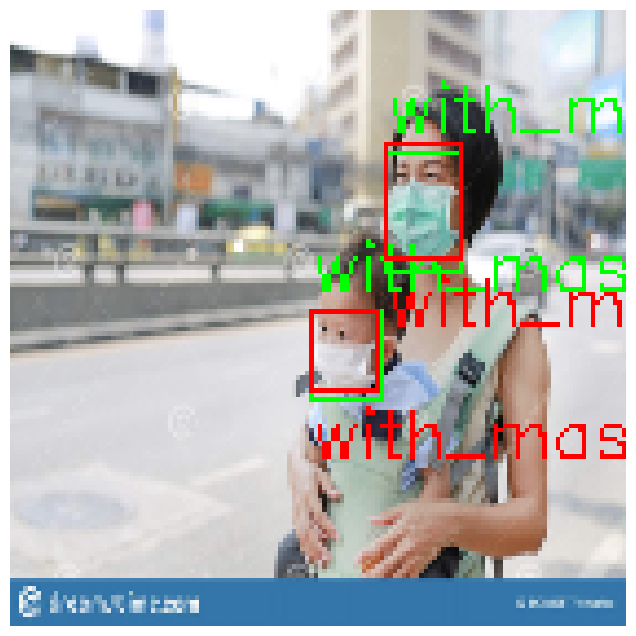

In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

image, bboxes, labels = valset[17]

image_batch = image.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(image_batch)

pred = outputs[0]
pred_boxes = pred['boxes'].cpu().numpy()
pred_labels = pred['labels'].cpu().numpy()
pred_scores = pred['scores'].cpu().numpy()

gt_boxes = bboxes.cpu().numpy() if isinstance(bboxes, torch.Tensor) else np.array(bboxes)
gt_labels = labels

img_np = image.permute(1,2,0).numpy()
img_np = (img_np * 255).astype(np.uint8)
img_plot = img_np.copy()

for bbox, label in zip(gt_boxes, gt_labels):
    xmin, ymin, xmax, ymax = map(int, bbox)
    color = (0, 255, 0)
    cv2.rectangle(img_plot, (xmin, ymin), (xmax, ymax), color, 1)
    cv2.putText(img_plot, label, (xmin, ymin-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

for bbox, label, score in zip(pred_boxes, pred_labels, pred_scores):
    if score < 0.5:
        continue
    xmin, ymin, xmax, ymax = map(int, bbox)
    for k, v in class_to_idx.items():
        if v == label:
            class_name = k
            break
    color = (255, 0, 0)
    cv2.rectangle(img_plot, (xmin, ymin), (xmax, ymax), color, 1)
    cv2.putText(img_plot, f"{class_name}", (xmin, ymax+15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

plt.figure(figsize=(10,8))
plt.imshow(img_plot)
plt.axis("off")
plt.show()

Визуально мы видим, что зачастую модель довольно хорошо определяет как рамки так и метки.

## Куда сдавать?

По инструкции в гитхаб – https://shy-question-39d.notion.site/1150ea832e418032bfc3d3e827c380fb?pvs=74

- К этой работе тестов нет.
- Эту работу можно выполнить с кем-нибудь в паре или в гордом одиночестве.
- Пул-реквест нужно сделать в ветку `lab3`. Если вас двое, то можно 1 или 2 пул-реквеста, главное – отметьте как-нибудь, что выполняли в паре.

**Устная защита работ не требуется, но вам могут быть заданы вопросы прямо в вашем пул-реквесте!**